# Load Dataset

In [ ]:
# Download processed dataset from shared Drive
import gdown, zipfile, os

if not os.path.exists('dataset/processed'):
    FILE_ID = '1a7kCwqP2Vhlv43eep0ODdzGVR6v2ouP6'
    gdown.download(id=FILE_ID, output='processed.zip', quiet=False)
    with zipfile.ZipFile('processed.zip', 'r') as z:
        z.extractall('dataset/')
    os.remove('processed.zip')
else:
    print('Already downloaded.')

Already downloaded.


In [ ]:
# Load shared splits and ID mappings
import pandas as pd
import numpy as np
import pickle

train_df = pd.read_csv('dataset/processed/train.csv')
val_df   = pd.read_csv('dataset/processed/val.csv')
test_df  = pd.read_csv('dataset/processed/test.csv')
games_df = pd.read_csv('dataset/processed/games_cleaned.csv')

with open('dataset/processed/id_maps.pkl', 'rb') as f:
    maps = pickle.load(f)

n_users = len(maps['user2idx'])
n_items = len(maps['item2idx'])

print(f'n_users: {n_users:,} | n_items: {n_items:,}')
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

n_users: 272,184 | n_items: 21,922
Train: 18,151,978 | Val: 272,184 | Test: 272,184


# DeepFM Model

In [ ]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# fix all seeds
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

In [ ]:
import torch.nn as nn

class DeepFMPyTorch(nn.Module):
    def __init__(self, field_dims, num_factors, mlp_dims, dense_dim, drop_rate=0.1):
        super(DeepFMPyTorch, self).__init__()

        self.embedding = nn.Embedding(sum(field_dims), num_factors)
        self.fc = nn.Embedding(sum(field_dims), 1)

        # Store offsets as plain list
        self.offsets = [0] + np.cumsum(field_dims).tolist()[:-1]

        self.dense_linear = nn.Linear(dense_dim, 1)
        input_dim = (len(field_dims) * num_factors) + dense_dim
        layers = []
        for dim in mlp_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(drop_rate))
            input_dim = dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_num):
        # Apply offsets — shift each field into the correct embedding range
        for i, offset in enumerate(self.offsets):
            x_cat[:, i] = x_cat[:, i] + offset

        # FM Component
        embed_x = self.embedding(x_cat) # [batch_size, num_fields, num_factors]

        # square of sum
        square_of_sum = torch.sum(embed_x, dim=1)**2
        # sum of square
        sum_of_square = torch.sum(embed_x**2, dim=1)

        fm_out = 0.5 * torch.sum(square_of_sum - sum_of_square, dim=1, keepdim=True)

        # Linear (Order-1) Component
        linear_out = torch.sum(self.fc(x_cat), dim=1)
        dense_linear_out = self.dense_linear(x_num)
        linear_out += dense_linear_out

        # Deep Component
        # Flatten embeddings for the MLP and add numerical data
        mlp_in = torch.cat([embed_x.view(x_cat.size(0), -1), x_num], dim=1)
        deep_out = self.mlp(mlp_in)

        # Final Output
        return linear_out + fm_out + deep_out

# Data Preprocessing

In [ ]:
# converting the hot-encoded category features back to category idx
cat_cols = [col for col in games_df.columns if col.startswith('Cat:')]
def get_category_names(row):
    active = sorted([col.replace('Cat:', '') for col in cat_cols if row[col] == 1])
    if not active:
        return 'unknown'
    return ','.join(active)

games_df['Category'] = games_df[cat_cols].apply(get_category_names, axis=1)
games_df['category_idx'] = pd.Categorical(games_df['Category']).codes

In [ ]:
sparse_cols = ['user_idx', 'item_idx', 'category_idx']
dense_cols = ['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'MfgAgeRec']

# merge user ratings with game data
full_train_df = train_df.merge(games_df[['BGGId', 'category_idx'] + dense_cols + cat_cols], on='BGGId', how='left')
full_val_df   = val_df.merge(games_df[['BGGId', 'category_idx'] + dense_cols + cat_cols], on='BGGId', how='left')
full_test_df  = test_df.merge(games_df[['BGGId', 'category_idx'] + dense_cols + cat_cols], on='BGGId', how='left')


In [ ]:
field_dims = [
    full_train_df['user_idx'].nunique(),
    full_train_df['item_idx'].nunique(),
    full_train_df['category_idx'].nunique(),
]
print(f"Field Dimensions: {field_dims}")

Field Dimensions: [272184, 21922, 40]


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize numerical columns
scaler = StandardScaler()
full_train_df[dense_cols] = scaler.fit_transform(full_train_df[dense_cols].fillna(0))
full_val_df[dense_cols]   = scaler.transform(full_val_df[dense_cols].fillna(0))
full_test_df[dense_cols]  = scaler.transform(full_test_df[dense_cols].fillna(0))

In [ ]:
# feature lookup
item_map_df = pd.DataFrame({
    'BGGId': list(maps['item2idx'].keys()),
    'item_idx': list(maps['item2idx'].values()),
})
game_features = item_map_df.merge(games_df, on='BGGId', how='left').set_index('item_idx')
game_features[dense_cols]  = scaler.transform(game_features[dense_cols].fillna(0))

all_item_ids    = game_features.index.to_numpy(dtype=np.int64)
item_sparse_array = game_features[sparse_cols[2:]].to_numpy(dtype=np.int64)
item_dense_array  = game_features[dense_cols].to_numpy(dtype=np.float32)
item_id_to_pos  = {item_id: idx for idx, item_id in enumerate(game_features.index)}

In [ ]:
from torch.utils.data import Dataset, DataLoader

class BPRDataset(Dataset):
    def __init__(self, interactions_df, seen, sparse_cols, dense_cols, seed=42):
        self.interactions    = interactions_df[['user_idx', 'item_idx']].to_numpy(dtype=np.int64)
        self.seen            = seen
        self.rng             = np.random.default_rng(seed)
        self.n_items         = len(all_item_ids)
        item_counts = interactions_df['item_idx'].value_counts()
        top_k = 1000
        self.popular_items = item_counts.index[:top_k].to_numpy(dtype=np.int64)
        self.pop_ratio = 0.3

    def __len__(self):
        return len(self.interactions)

    def __getitem__(self, idx):
        uid, pos_item = self.interactions[idx]
        uid, pos_item = int(uid), int(pos_item)

        # Negative sampling
        user_seen = self.seen[uid]

        # sample more popular games
        neg_item = None
        for _ in range(10):
            if self.rng.random() < self.pop_ratio:
                neg_item = int(self.popular_items[self.rng.integers(len(self.popular_items))])
            else:
                neg_item = int(all_item_ids[self.rng.integers(self.n_items)])

            if neg_item not in user_seen:
                break

        while neg_item in user_seen:
            neg_item = int(all_item_ids[self.rng.integers(self.n_items)])

        pos_idx = item_id_to_pos[pos_item]
        neg_idx = item_id_to_pos[neg_item]

        x_cat_pos = np.array([uid, pos_item, *item_sparse_array[pos_idx]], dtype=np.int64)
        x_cat_neg = np.array([uid, neg_item, *item_sparse_array[neg_idx]], dtype=np.int64)

        return (
            torch.tensor(x_cat_pos, dtype=torch.long),
            torch.tensor(item_dense_array[pos_idx], dtype=torch.float32),
            torch.tensor(x_cat_neg, dtype=torch.long),
            torch.tensor(item_dense_array[neg_idx], dtype=torch.float32),
        )

# Evaluation Function

In [ ]:
from tqdm import tqdm

seen_train = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
seen_val = val_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

seen = {
    u: seen_train.get(u, set()) | seen_val.get(u, set())
    for u in set(seen_train) | set(seen_val)
}
def evaluate_deepfm(model, test_df, seen, n_negatives=99, K=10,
                    sparse_cols=None, dense_cols=None, verbose=True):
    hits, ndcgs, mrrs = [], [], []

    model.eval()
    with torch.no_grad():
        for _, row in tqdm(test_df.iterrows(), total=len(test_df),
                           desc="Evaluating", disable=not verbose):
            uid      = int(row['user_idx'])
            pos_item = int(row['item_idx'])

            # Negative sampling
            user_seen  = seen.get(uid, set()) | {pos_item}
            candidates = np.setdiff1d(all_item_ids, list(user_seen))
            neg_items = np.random.choice(candidates, size=n_negatives, replace=False)
            items_to_rank = np.append(neg_items, pos_item)

            # Build tensors
            idxs         = np.array([item_id_to_pos[i] for i in items_to_rank])
            u_tensor     = torch.LongTensor([uid] * len(items_to_rank)).unsqueeze(1).to(device)
            i_tensor     = torch.LongTensor(items_to_rank).unsqueeze(1).to(device)
            other_sparse = torch.LongTensor(item_sparse_array[idxs]).to(device)
            x_cat        = torch.cat([u_tensor, i_tensor, other_sparse], dim=1)
            x_num        = torch.FloatTensor(item_dense_array[idxs]).to(device)

            # Predict and rank
            preds         = model(x_cat, x_num).squeeze().cpu().numpy()
            ranked_items  = items_to_rank[np.argsort(-preds)]
            pos_rank      = int(np.where(ranked_items == pos_item)[0][0]) + 1

            hits.append(1 if pos_rank <= K else 0)
            ndcgs.append(np.log(2) / np.log(pos_rank + 1) if pos_rank <= K else 0)
            mrrs.append(1 / pos_rank if pos_rank <= K else 0)

    return {
        f'HR@{K}':   np.mean(hits),
        f'NDCG@{K}': np.mean(ndcgs),
        f'MRR@{K}':  np.mean(mrrs),
    }


# Training Functions

In [ ]:
def build_dataloader(interactions_df, sparse_cols, dense_cols,
                     batch_size=4096, num_workers=4, seed=42):
    dataset = BPRDataset(
        interactions_df=interactions_df,
        seen=seen_train,
        sparse_cols=sparse_cols,
        dense_cols=dense_cols,
        seed=seed,
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=num_workers, pin_memory=True)
    return loader

def build_model(field_dims, num_factors, mlp_dims, dense_dim, drop_rate, device):
    model = DeepFMPyTorch(
        field_dims,
        num_factors=num_factors,
        mlp_dims=mlp_dims,
        dense_dim=dense_dim,
        drop_rate=drop_rate,
    ).to(device)
    return model

In [ ]:
def train_model(start_epoch, end_epoch, train_loader, model, optimizer, scaler_amp, best_val_hr, patience_counter=0, patience=3, train=True,  val_every=1):

  train_losses = []
  val_epochs = []
  val_hrs = []
  val_ndcgs = []
  val_mrrs = []
  val_results = {
    'HR@10':   0.0,
    'NDCG@10': 0.0,
    'MRR@10':  0.0,
}

  for e in range(start_epoch, end_epoch):

      model.train()

      loop = tqdm(train_loader, desc=f"Epoch {e+1}/{end_epoch}")
      epoch_loss = 0.0

      for x_cat_pos, x_num_pos, x_cat_neg, x_num_neg in loop:
        x_cat_pos = x_cat_pos.to(device)
        x_num_pos = x_num_pos.to(device)
        x_cat_neg = x_cat_neg.to(device)
        x_num_neg = x_num_neg.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', dtype=torch.float16):
            pos_score = model(x_cat_pos, x_num_pos).squeeze(-1)
            neg_score = model(x_cat_neg, x_num_neg).squeeze(-1)
            loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())
      avg_loss = epoch_loss / len(train_loader)
      train_losses.append(avg_loss)
      print(f"  Epoch Loss: {avg_loss:.4f}")

      # Validation
      if (e + 1) % val_every == 0:
        val_sample = full_val_df.sample(n=5000, random_state=42)
        val_results = evaluate_deepfm(
            model=model,
            test_df=val_sample,
            seen=seen,
            n_negatives=99,
            K=10,
            sparse_cols=sparse_cols,
            dense_cols=dense_cols,
            verbose=train # show progress bar only in training
        )
        val_hr = val_results['HR@10']
        val_epochs.append(e + 1)
        val_hrs.append(val_hr)
        val_ndcgs.append(val_results['NDCG@10'])
        val_mrrs.append(val_results['MRR@10'])
        print(f"  Epoch {e+1} Val HR@10: {val_hr:.4f} | NDCG@10: {val_results['NDCG@10']:.4f} | MRR@10: {val_results['MRR@10']:.4f}")

        # Early Stopping - Execute only in training not tuning
        if train:
          if val_hr > best_val_hr:
              best_val_hr = val_hr
              patience_counter = 0
              torch.save(model.state_dict(), 'best_model.pt')
              print(f"  New best model (HR@10: {best_val_hr:.4f})")
          else:
              patience_counter += 1
              print(f"  No improvement. Patience: {patience_counter}/{patience}")
              if patience_counter >= patience:
                  print('  Early stopping triggered.')
                  break
        print()
  # load best model
  if train:
    model.load_state_dict(torch.load('best_model.pt', weights_only = False))
    return model, train_losses, val_epochs, val_hrs, val_ndcgs, val_mrrs, best_val_hr, patience_counter
  else:
    return val_results

# Hyperparameter Tuning

In [ ]:
import itertools

tune_df = full_train_df.groupby('user_idx').tail(5).reset_index(drop=True)

param_grid = {
    'num_factors': [16, 32, 64],
    'mlp_dims':    [[256, 128, 64], [512, 256, 128]],
    'drop_rate':   [0.1, 0.2],
    'lr':          [0.001]
}

keys, values = zip(*param_grid.items())
configs = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total configs: {len(configs)}")

tune_results = []
for i, cfg in enumerate(configs):
    print(f"\n-Config {i+1}/{len(configs)}: {cfg}")

    tune_loader = build_dataloader(interactions_df=tune_df,
                                sparse_cols=sparse_cols,
                                dense_cols=dense_cols,
                                batch_size=4096,
                                seed=42)

    tune_model = build_model(field_dims,
                            cfg['num_factors'],
                            cfg['mlp_dims'],
                            len(dense_cols),
                            cfg['drop_rate'], device)
    optimizer  = torch.optim.Adam(tune_model.parameters(), lr=cfg['lr'], weight_decay=1e-6)
    scaler_amp = torch.amp.GradScaler('cuda')

    results = train_model(start_epoch=0,
                  end_epoch=5,
                  train_loader=tune_loader,
                  model=tune_model,
                  optimizer=optimizer,
                  scaler_amp=scaler_amp,
                  best_val_hr=0,
                  patience_counter=0,
                  patience=3,
                  train=False,
                  val_every = 1)
    tune_results.append({**cfg, **results})

print("\nHyperparameter Search Results")
tune_results_df = pd.DataFrame(tune_results).sort_values('HR@10', ascending=False)
print(tune_results_df.to_string(index=False))

# Best config
best_cfg = tune_results_df.iloc[0]
print(f"\nBest config: num_factors={int(best_cfg['num_factors'])}, "
      f"mlp_dims={best_cfg['mlp_dims']}, "
      f"drop_rate={best_cfg['drop_rate']}, "
      f"lr={best_cfg['lr']}")



Total configs: 12

-Config 1/12: {'num_factors': 16, 'mlp_dims': [256, 128, 64], 'drop_rate': 0.1, 'lr': 0.001}


Epoch 1/5: 100%|██████████| 325/325 [00:28<00:00, 11.40it/s, loss=1.13]


  Epoch Loss: 1.7838
  Epoch 1 Val HR@10: 0.2036 | NDCG@10: 0.0935 | MRR@10: 0.0608



Epoch 2/5: 100%|██████████| 325/325 [00:28<00:00, 11.23it/s, loss=1.01]


  Epoch Loss: 0.9921
  Epoch 2 Val HR@10: 0.2188 | NDCG@10: 0.1020 | MRR@10: 0.0672



...

  Epoch Loss: 1.5556
  Epoch 3 Val HR@10: 0.2588 | NDCG@10: 0.1216 | MRR@10: 0.0805



Epoch 4/5: 100%|██████████| 325/325 [00:27<00:00, 11.70it/s, loss=1.18]


  Epoch Loss: 1.3197
  Epoch 4 Val HR@10: 0.2682 | NDCG@10: 0.1259 | MRR@10: 0.0835



Epoch 5/5: 100%|██████████| 325/325 [00:27<00:00, 11.84it/s, loss=1.18]


  Epoch Loss: 1.1719
  Epoch 5 Val HR@10: 0.2700 | NDCG@10: 0.1270 | MRR@10: 0.0845


Hyperparameter Search Results
 num_factors        mlp_dims  drop_rate    lr  HR@10  NDCG@10   MRR@10
          64 [512, 256, 128]        0.1 0.001 0.2760 0.128953 0.085170
          64  [256, 128, 64]        0.2 0.001 0.2730 0.125620 0.081913
          32 [512, 256, 128]        0.1 0.001 0.2702 0.127736 0.085389
          64 [512, 256, 128]        0.2 0.001 0.2700 0.126984 0.084521
          32 [512, 256, 128]        0.2 0.001 0.2696 0.129706 0.087982
          16  [256, 128, 64]        0.2 0.001 0.2654 0.128070 0.087152
          32  [256, 128, 64]        0.1 0.001 0.2634 0.124204 0.082710
          16 [512, 256, 128]        0.2 0.001 0.2618 0.123292 0.082143
          64  [256, 128, 64]        0.1 0.001 0.2596 0.117677 0.075604
          16 [512, 256, 128]        0.1 0.001 0.2592 0.123860 0.083555
          32  [256, 128, 64]        0.2 0.001 0.2574 0.119089 0.078234
          16  [256, 128, 64]    

# Training

In [ ]:
# set best configurations

# num_factors = best_cfg['num_factors']
# mlp_dims = best_cfg['mlp_dims']
# drop_rate = best_cfg['drop_rate']
# lr = best_cfg['lr']

num_factors = 16 # lowered embeddings to give more weight to dense features
mlp_dims = [512, 256, 128]
drop_rate = 0.1
lr = 0.001

In [ ]:
train_loader = build_dataloader(interactions_df=full_train_df,
                                sparse_cols=sparse_cols,
                                dense_cols=dense_cols,
                                batch_size=4096,
                                seed=42)


# double check dimensions
print(f"field_dims: {field_dims}")
print(f"dense_dim: {len(dense_cols)}")
print(f"sparse_cols: {sparse_cols}")

deepFM_model = build_model(field_dims,
                        num_factors,
                        mlp_dims,
                        len(dense_cols),
                        drop_rate, device)

optimizer  = torch.optim.Adam(deepFM_model.parameters(), lr=lr, weight_decay=1e-6)
scaler_amp = torch.amp.GradScaler('cuda')

field_dims: [272184, 21922, 40]
dense_dim: 5
sparse_cols: ['user_idx', 'item_idx', 'category_idx']


In [ ]:
# Training
end_epoch = 10
deepFM_model, train_losses, val_epochs, val_hrs, val_ndcgs, val_mrrs, best_val_hr, patience_counter = train_model(start_epoch=0, end_epoch=end_epoch,
                                                                                                      train_loader=train_loader,
                                                                                                      model=deepFM_model,
                                                                                                      optimizer=optimizer,
                                                                                                      scaler_amp=scaler_amp,
                                                                                                      best_val_hr=0,
                                                                                                      patience_counter=0,
                                                                                                      patience=5,
                                                                                                      train=True,
                                                                                                      val_every=1)

Epoch 1/10: 100%|██████████| 4432/4432 [08:00<00:00,  9.23it/s, loss=0.423]


  Epoch Loss: 0.5438


Evaluating: 100%|██████████| 5000/5000 [00:14<00:00, 351.36it/s]


  Epoch 1 Val HR@10: 0.3358 | NDCG@10: 0.1755 | MRR@10: 0.1275
  New best model (HR@10: 0.3358)



Epoch 2/10: 100%|██████████| 4432/4432 [07:54<00:00,  9.35it/s, loss=0.354]


...

  Epoch 9 Val HR@10: 0.5870 | NDCG@10: 0.3284 | MRR@10: 0.2494
  No improvement. Patience: 1/5



Epoch 10/10: 100%|██████████| 4432/4432 [07:08<00:00, 10.35it/s, loss=0.182]


  Epoch Loss: 0.2090


Evaluating: 100%|██████████| 5000/5000 [00:11<00:00, 420.60it/s]

  Epoch 10 Val HR@10: 0.6024 | NDCG@10: 0.3366 | MRR@10: 0.2554
  New best model (HR@10: 0.6024)



In [ ]:
# save checkpoint states
file_name = f"checkpoint_epoch{end_epoch}.pt"
torch.save({
    'epoch': end_epoch,
    'model_state_dict': deepFM_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler_state_dict': scaler_amp.state_dict(),
    'best_val_hr': best_val_hr,
    'patience_counter': patience_counter,
}, file_name)

# save locally in case runtime terminates
# from google.colab import files
# files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# reload model to continue training and testing

# checkpoint = torch.load('checkpoint_epoch10.pt', weights_only=False)
# deepFM_model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# scaler_amp.load_state_dict(checkpoint['scaler_state_dict'])
# best_val_hr = checkpoint['best_val_hr']
# patience_counter = checkpoint['patience_counter']
# start_epoch = checkpoint['epoch']  # resume from next epoch

In [ ]:
# start_epoch = 10
# end_epoch = 20
# deepFM_model_20, train_losses2, val_epochs2, val_hrs2, val_ndcgs2, val_mrrs2, best_val_hr2, patience_counter = train_model(start_epoch=start_epoch, end_epoch=end_epoch,
#                                                                                                       train_loader=train_loader,
#                                                                                                       model=deepFM_model,
#                                                                                                       optimizer=optimizer,
#                                                                                                       scaler_amp=scaler_amp,
#                                                                                                       best_val_hr=best_val_hr,
#                                                                                                       patience_counter=0,
#                                                                                                       patience=5,
#                                                                                                       train=True,
#                                                                                                       val_every=1)

# Results

In [ ]:
# Run the evaluation for 1 positive vs 99 negatives
results = evaluate_deepfm(
    model=deepFM_model,
    test_df=full_test_df,
    seen=seen,
    n_negatives=99,
    K=10,
    sparse_cols=sparse_cols,
    dense_cols=dense_cols
)

print("\nFinal Test Metrics (10 epochs)")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

Evaluating: 100%|██████████| 272184/272184 [10:41<00:00, 424.09it/s]



Final Test Metrics (10 epochs)
HR@10: 0.4257
NDCG@10: 0.2230
MRR@10: 0.1618


In [ ]:
import matplotlib.pyplot as plt

def plot_train_loss(train_losses):
    plt.figure(figsize=(7, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', markersize=4)
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('BPR Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_val_metrics(val_epochs, val_hrs, val_ndcgs, val_mrrs):
    plt.figure(figsize=(7, 5))
    plt.plot(val_epochs, val_hrs,   'g-o', markersize=4, label='HR@10')
    plt.plot(val_epochs, val_ndcgs, 'r-o', markersize=4, label='NDCG@10')
    plt.plot(val_epochs, val_mrrs,  'b-o', markersize=4, label='MRR@10')
    plt.title('Validation Metrics per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('val_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()


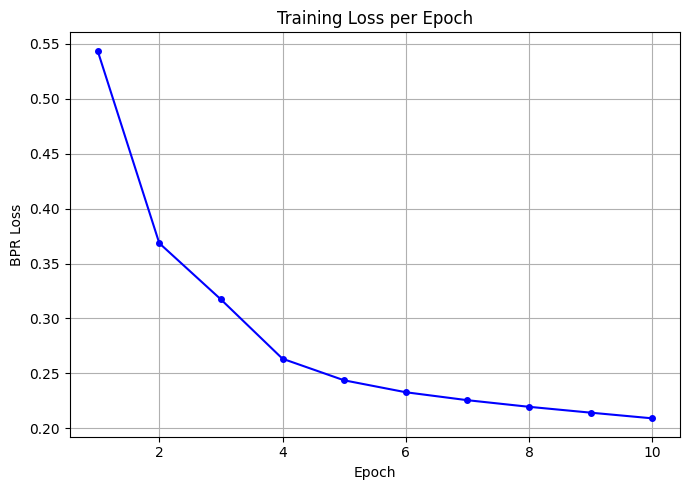

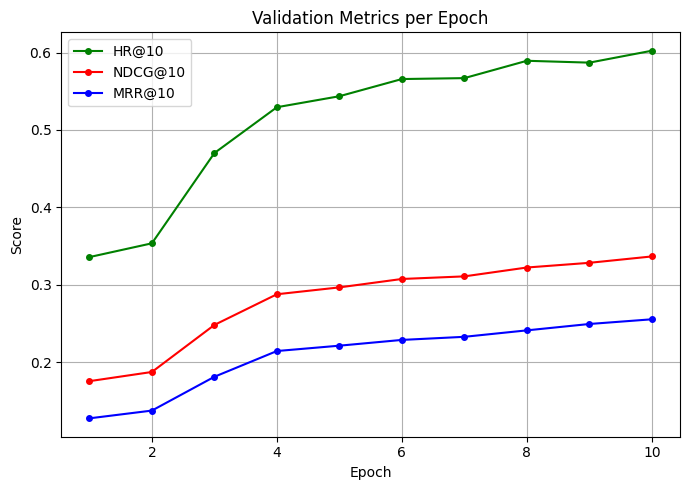

In [ ]:
plot_train_loss(train_losses)
plot_val_metrics(val_epochs, val_hrs, val_ndcgs, val_mrrs)

# Sample Recommendations

In [ ]:
idx_to_bggid = maps['idx2item']
games_lookup  = games_df.set_index('BGGId')[['Name', 'AvgRating']]

def get_recommendations_deepfm(user_idx, model,seen,
                                sparse_cols, dense_cols, top_k=10):
    model.eval()
    with torch.no_grad():
        user_seen    = seen.get(user_idx, set())
        unseen_items = np.array([i for i in all_item_ids if i not in user_seen])

        idxs = np.array([item_id_to_pos[i] for i in unseen_items])
        u_tensor     = torch.LongTensor([user_idx] * len(unseen_items)).unsqueeze(1).to(device)
        i_tensor     = torch.LongTensor(unseen_items).unsqueeze(1).to(device)
        other_sparse = torch.LongTensor(item_sparse_array[idxs]).to(device)
        x_cat        = torch.cat([u_tensor, i_tensor, other_sparse], dim=1)
        x_num        = torch.FloatTensor(item_dense_array[idxs]).to(device)
        scores       = model(x_cat, x_num).squeeze().cpu().numpy()

    top_indices  = np.argsort(-scores)[:top_k]
    top_item_ids = unseen_items[top_indices]
    top_scores   = scores[top_indices]

    bgg_ids = [idx_to_bggid[i] for i in top_item_ids]
    recs    = games_lookup.loc[bgg_ids].copy()
    recs['DeepFM_Score'] = top_scores
    return recs.reset_index()

# Sample 3 users from test set
sample_users = test_df['user_idx'].sample(3, random_state=42).tolist()
for uid in sample_users:
    username  = maps['idx2user'][uid]
    num_rated = len(train_df[train_df['user_idx'] == uid])
    print(f'\nTop 10 recommendations for user {username} | Rated {num_rated} games:')
    print(get_recommendations_deepfm(uid, deepFM_model, seen,
                                     sparse_cols, dense_cols).to_string(index=False))


Top 10 recommendations for user VincentParadise | Rated 7 games:
 BGGId                              Name  AvgRating  DeepFM_Score
   822                       Carcassonne    7.41883      3.503696
 30549                          Pandemic    7.59130      3.434400
    13                             Catan    7.13746      3.051764
169786                            Scythe    8.21978      2.999523
146021                   Eldritch Horror    7.78712      2.948252
178900                         Codenames    7.60087      2.858227
167791                 Terraforming Mars    8.41879      2.853810
150376 Dead of Winter: A Crossroads Game    7.54665      2.825974
 36218                          Dominion    7.61081      2.793365
205637      Arkham Horror: The Card Game    8.16597      2.791556

Top 10 recommendations for user Anrab | Rated 7 games:
 BGGId              Name  AvgRating  DeepFM_Score
   822       Carcassonne    7.41883      3.631897
 30549          Pandemic    7.59130      3.543328
  

In [ ]:
# count how often each item appears in training
item_popularity = train_df['item_idx'].value_counts().reset_index()
item_popularity.columns = ['item_idx', 'interaction_count']

for uid in sample_users:
    recs = get_recommendations_deepfm(uid, deepFM_model, seen, sparse_cols, dense_cols)
    bgg_ids = recs['BGGId'].tolist()

    item_ids = [maps['item2idx'][b] for b in bgg_ids]
    pop = item_popularity[item_popularity['item_idx'].isin(item_ids)]['interaction_count']
    print(f"User {uid} : avg popularity of recommended items: {pop.mean()} interactions")

    cats = game_features.loc[[maps['item2idx'][b] for b in bgg_ids], 'category_idx']
    print(f"User {uid} : unique categories in top 10: {cats.nunique()} / 10")

# compare against average item
print(f"\nAverage item popularity overall: {item_popularity['interaction_count'].mean():.0f}")

User 132734 : avg popularity of recommended items: 69430.6 interactions
User 132734 : unique categories in top 10: 6 / 10
User 6480 : avg popularity of recommended items: 79256.0 interactions
User 6480 : unique categories in top 10: 5 / 10
User 139088 : avg popularity of recommended items: 21293.8 interactions
User 139088 : unique categories in top 10: 6 / 10

Average item popularity overall: 828
